## Based on make_LSSCats_v1.ipynb, output the LSS cat from fiber assigned targets. --06-30-2026
1. Removed FRAC_TLOBS_TILES and FRACZ_TILELOCID from the pipeline and output.
2. Added COMPLETENESS_WEIGHT from parent/assigned HEALPix pixel counts (A/B).

In [1]:
import os, glob
import numpy as np
import healpy as hp
from astropy.table import Table, vstack, join
import matplotlib.pyplot as plt
from multiprocessing import get_context
#import argparse

In [2]:
def process_one_fba_file(infile):
    """Read one tile FITS and build assigned table for that tile."""
    cat_assigned = Table.read(infile, hdu=1)

    tile_id = int(os.path.basename(infile).split("_")[-1].split(".")[0])
    tile_id64 = np.int64(tile_id)
    assigned_fiber = np.asarray(cat_assigned["FIBERID"], dtype=np.int64)

    cat_assigned["TILEID"] = tile_id64
    cat_assigned["TILELOCID"] = tile_id64 * np.int64(10000) + assigned_fiber

    return tile_id, cat_assigned


def _target_tiles_fibers_for_block(target_id, tile_block, fiber_block):
    """Format TILES and FIBERS strings for one TARGETID block."""
    if tile_block.size == 1:
        return (
            int(target_id),
            str(int(tile_block[0])),
            str(int(fiber_block[0])),
        )
    pair_change = np.r_[
        True,
        (tile_block[1:] != tile_block[:-1]) | (fiber_block[1:] != fiber_block[:-1]),
    ]
    tiles_u = tile_block[pair_change]
    fibers_u = fiber_block[pair_change]
    return (
        int(target_id),
        "-".join(map(str, tiles_u.tolist())),
        "-".join(map(str, fibers_u.tolist())),
    )


def _aggregate_assigned_group_chunk(t_sorted, tile_sorted, fiber_sorted, group_starts, group_ends, i0, i1):
    rows = []
    for gi in range(i0, i1):
        s = int(group_starts[gi])
        e = int(group_ends[gi])
        rows.append(
            _target_tiles_fibers_for_block(
                t_sorted[s], tile_sorted[s:e], fiber_sorted[s:e]
            )
        )
    return rows


def aggregate_assigned_by_target(cat_assigned_dict, n_workers=1, tiles_dtype="U64", fibers_dtype="U64"):
    """One row per TARGETID with TILES and FIBERS hyphen lists in matching order."""
    all_assigned = vstack(
        [cat_assigned_dict[k]["TARGETID", "FIBERID", "TILEID"] for k in cat_assigned_dict]
    )

    target_ids = np.asarray(all_assigned["TARGETID"])
    tile_ids = np.asarray(all_assigned["TILEID"], dtype=np.int64)
    fiber_ids = np.asarray(all_assigned["FIBERID"], dtype=np.int64)

    order = np.lexsort((fiber_ids, tile_ids, target_ids))
    t_sorted = target_ids[order]
    tile_sorted = tile_ids[order]
    fiber_sorted = fiber_ids[order]

    n = len(t_sorted)
    group_starts = np.r_[0, 1 + np.flatnonzero(t_sorted[1:] != t_sorted[:-1])]
    group_ends = np.r_[group_starts[1:], n]
    n_groups = len(group_starts)

    if n_workers <= 1:
        rows = _aggregate_assigned_group_chunk(
            t_sorted, tile_sorted, fiber_sorted, group_starts, group_ends, 0, n_groups
        )
    else:
        ctx = get_context("fork")
        chunk_groups = max(1, n_groups // (n_workers * 4))
        tasks = []
        for i0 in range(0, n_groups, chunk_groups):
            i1 = min(n_groups, i0 + chunk_groups)
            tasks.append((t_sorted, tile_sorted, fiber_sorted, group_starts, group_ends, i0, i1))
        rows = []
        with ctx.Pool(processes=n_workers) as pool:
            for chunk in pool.starmap(_aggregate_assigned_group_chunk, tasks):
                rows.extend(chunk)

    target_out, tiles_out, fibers_out = zip(*rows)
    return Table(
        {
            "TARGETID": np.asarray(target_out, dtype=np.int64),
            "TILES": np.array(tiles_out, dtype=tiles_dtype),
            "FIBERS": np.array(fibers_out, dtype=fibers_dtype),
        }
    )


def count_targets_per_healpix_pixel(ra_deg, dec_deg, nside, nest=False):
    """Return HEALPix pixel ID per target and total target count in each pixel."""
    ra_deg = np.asarray(ra_deg, dtype=np.float64)
    dec_deg = np.asarray(dec_deg, dtype=np.float64)
    pix = hp.ang2pix(nside, ra_deg, dec_deg, lonlat=True, nest=nest).astype(np.int64)
    npix = hp.nside2npix(nside)
    return pix, np.bincount(pix, minlength=npix)


def lookup_healpix_for_targetids(target_ids, parent_ids, parent_pix):
    """Map output TARGETIDs to parent HEALPix pixel IDs."""
    target_ids = np.asarray(target_ids)
    order = np.argsort(parent_ids)
    sorted_ids = parent_ids[order]
    sorted_pix = parent_pix[order]
    pos = np.searchsorted(sorted_ids, target_ids)
    if not np.all(sorted_ids[pos] == target_ids):
        missing = target_ids[sorted_ids[pos] != target_ids]
        raise ValueError(f"{len(missing)} TARGETIDs missing from parent catalog")
    return sorted_pix[pos]


def add_completeness_weight(output, cat_parent, nside, nest=False, weight_col="COMP_FA"):
    """
    Add A/B = fiber assigned completeness per HEALPix pixel, where
      A = number of fiber-assigned output targets in the pixel
      B = number of parent-catalog targets in the pixel 
    """
    parent_ids = np.asarray(cat_parent["idx"])
    pix_parent, count_parent = count_targets_per_healpix_pixel(
        cat_parent["ra"], cat_parent["dec"], nside, nest=nest
    )
    pix_output = lookup_healpix_for_targetids(output["TARGETID"], parent_ids, pix_parent)

    npix = hp.nside2npix(nside)
    count_fa = np.bincount(pix_output, minlength=npix)

    count_parent_row = count_parent[pix_output]
    count_fa_row = count_fa[pix_output]
    if np.any(count_parent_row == 0):
        raise ValueError("Found parent targets in pixels with zero count")

    output[weight_col] = count_fa_row.astype(np.float64) / count_parent_row.astype(np.float64)
    return output


def build_completeness_map(count_fa, count_parent, nside):
    """Build per-pixel completeness = n_assigned / n_parent on the parent footprint."""
    npix = hp.nside2npix(nside)
    weight_map = np.full(npix, hp.UNSEEN, dtype=np.float64)

    in_parent = count_parent > 0
    weight_map[in_parent] = 0.0
    assigned = count_fa > 0
    weight_map[assigned] = (
        count_fa[assigned].astype(np.float64) / count_parent[assigned].astype(np.float64)
    )
    return weight_map, in_parent, assigned


def _clip_cartview_ranges(ra_range, dec_range, pad_deg=1.0):
    """Clip lonra/latra to ranges accepted by healpy cartview."""
    ra0 = float(ra_range[0]) - pad_deg
    ra1 = float(ra_range[1]) + pad_deg
    dec0 = max(-90.0, float(dec_range[0]) - pad_deg)
    dec1 = min(90.0, float(dec_range[1]) + pad_deg)
    if dec0 >= dec1:
        dec1 = min(90.0, dec0 + 0.5)
    if ra0 >= ra1:
        ra1 = ra0 + 0.5
    return (ra0, ra1), (dec0, dec1)


def plot_completeness_map(
    count_fa,
    count_parent,
    nside,
    nest=False,
    n_passes=3,
    ra_range=(0.0, 90.0),
    dec_range=(0.0, 90.0),
):
    """Cartview + histogram for fiber assignment completeness on the parent footprint."""
    weight_map, in_parent, assigned = build_completeness_map(
        count_fa, count_parent, nside
    )
    parent_weights = weight_map[in_parent]
    assigned_weights = weight_map[assigned]

    vmin, vmax = 0.0, 1.0
    p2, p50, p98 = np.percentile(assigned_weights, [2, 50, 98])
    ra_range, dec_range = _clip_cartview_ranges(ra_range, dec_range)

    fig = plt.figure(figsize=(13, 10))
    hp.cartview(
        weight_map,
        nest=nest,
        coord="C",
        lonra=[ra_range[0], ra_range[1]],
        latra=[dec_range[0], dec_range[1]],
        min=vmin,
        max=vmax,
        title=f"Fiber assignment completeness ({n_passes} passes, HEALPix nside={nside})",
        unit="n_assigned / n_parent",
        cmap=plt.cm.RdYlGn,
        flip="astro",
        cbar=True,
        sub=(2, 1, 1),
    )
    hp.graticule(dmer=15, dpar=15, verbose=False)

    ax_hist = fig.add_subplot(2, 1, 2)
    ax_hist.hist(
        assigned_weights,
        bins=50,
        range=(0.0, 1.0),
        color="steelblue",
        edgecolor="white",
        linewidth=0.4,
    )
    ax_hist.axvline(p50, color="crimson", ls="--", lw=1.5, label=f"median={p50:.3f}")
    ax_hist.axvline(np.mean(assigned_weights), color="black", ls=":", lw=1.5,
                    label=f"mean={np.mean(assigned_weights):.3f}")
    ax_hist.set_xlim(0.0, 1.0)
    ax_hist.set_xlabel("Completeness per HEALPix pixel")
    ax_hist.set_ylabel("Number of pixels")
    ax_hist.set_title("Distribution on pixels with at least one assignment")
    ax_hist.legend(loc="upper left")

    summary = (
        f"parent footprint pixels={in_parent.sum():,}; "
        f"assigned pixels={assigned.sum():,}; "
        f"completeness min={assigned_weights.min():.3f}, "
        f"max={assigned_weights.max():.3f}, "
        f"p2={p2:.3f}, p98={p98:.3f}"
    )
    fig.text(0.08, 0.02, summary, ha="left", va="bottom", fontsize=10)
    fig.subplots_adjust(bottom=0.08, hspace=0.25)
    plt.show()

    return weight_map

In [3]:
mock_version = "v1"
Npasses = 3
seed = 100
dir_root = f"/home/zjding/fiberassignment/JUST/BGS_mock/Junyu_mock/fba/output/{mock_version}/{Npasses}passes/11987tiles_0.0ra90.0_0.0dec90.0/seed{seed}/"
filename = "fba_tile_{tid}.fits"

In [4]:
%%time
all_files = []
for pid in range(Npasses):
    file_list = sorted(glob.glob(dir_root + filename.format(tid=f"{pid+1}*")))
    print(f"pass={pid+1}, {len(file_list)} fba files")
    all_files.extend(file_list)

n_workers = min(16, os.cpu_count() or 1)
print(f"Processing {len(all_files)} files with {n_workers} workers")

cat_assigned_dict = {}
tileid_list = []

# fork pool: worker defined above is inherited by child processes on Linux
ctx = get_context("fork")
with ctx.Pool(processes=n_workers) as pool:
    for count, (tile_id, cat_assigned) in enumerate(
        pool.imap(process_one_fba_file, all_files, chunksize=32),
        start=1,
    ):
        key = f"TILE_{tile_id}"
        cat_assigned_dict[key] = cat_assigned
        tileid_list.append(tile_id)
        if count % 1000 == 0:
            print(count)

print(f"done: {len(tileid_list)} tiles")

pass=1, 3990 fba files
pass=2, 3987 fba files
pass=3, 3999 fba files
Processing 11976 files with 16 workers
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
done: 11976 tiles
CPU times: user 4.76 s, sys: 1.05 s, total: 5.81 s
Wall time: 38.5 s


In [5]:
%%time
## one row per TARGETID with TILES and FIBERS hyphen lists
n_agg_workers = min(16, os.cpu_count() or 1)
cat_assigned_all = aggregate_assigned_by_target(
    cat_assigned_dict,
    n_workers=n_agg_workers,
)
print("N_assigned_all_unique", len(cat_assigned_all))

output = cat_assigned_all
output

N_assigned_all_unique 11302616
CPU times: user 47.4 s, sys: 25.1 s, total: 1min 12s
Wall time: 1min 19s


TARGETID,TILES,FIBERS
int64,str64,str64
0,107393-207394,154-1052
2,207404,1382
3,207419,1721
5,207528-307528,309-1384
6,207541-307541,723-1813
7,107541-307528,586-1437
8,207541,1312
9,107592-207589-307585,1019-1715-413
10,207590,2170


In [6]:
## load the parent catalog and add fiber-assignment completeness weight
filepath = "/home/zjding/fiberassignment/JUST/BGS_mock/Junyu_mock/data/v1/lightcone_ra_0_90_dec_0_90_rmagcut20.5.fits"
cat_parent = Table.read(filepath)

nside = 256
nest = False

pix_parent, count_parent = count_targets_per_healpix_pixel(
    cat_parent["ra"], cat_parent["dec"], nside, nest=nest
)
pix_output = lookup_healpix_for_targetids(output["TARGETID"], cat_parent["idx"], pix_parent)
count_fa = np.bincount(pix_output, minlength=hp.nside2npix(nside))

n_parent_pixels = np.count_nonzero(count_parent)
n_output_pixels = np.count_nonzero(count_fa)
print(f"Parent targets: {len(cat_parent)}, pixels with n_target>0: {n_parent_pixels}")
print(f"Assigned output targets: {len(output)}, pixels with n_target>0: {n_output_pixels}")

output = add_completeness_weight(output, cat_parent, nside, nest=nest)
output["COMP_FA"][:10]

Parent targets: 13032492, pixels with n_target>0: 98560
Assigned output targets: 11302616, pixels with n_target>0: 97522


0.968503937007874
0.7073170731707317
0.9836065573770492
0.9918032786885246
0.9526627218934911
0.9918032786885246
0.9418604651162791
0.9865771812080537
0.8863636363636364
0.7522935779816514


In [7]:
cat_parent

Mh,Mr,Ms,dec,gr,idx,index,mr,ra,type,z
float64,float64,float64,float64,float64,int64,int64,float64,float64,int64,float64
292610000000000.0,-23.18849199726835,11.462036032248465,41.29154120855546,0.19434165954589844,0,0,9.956809619034223,49.80819359215435,1,0.01465678246071711
288760000000.0,-19.147627035161182,9.6715072838076,40.941039034384545,0.8027172088623047,1,1,14.064473284463798,49.73535385617138,1,0.012097661239719004
30740000000.0,-14.319385075304051,7.428143526326751,41.99001360921037,0.3145475387573242,2,2,18.782163312338206,51.97146451013884,1,0.017620778481114208
46437000000.0,-14.599905494564513,7.399693165043393,39.507130787443195,0.09915733337402344,3,9,18.60793481161047,47.154312077790685,1,0.013867155944747855
162300000000000.0,-21.502181387099878,10.918396168536269,40.08326168476845,0.8249874114990234,4,13,13.64869346210335,68.4822249425556,1,0.035229356999005645
309360000000.0,-19.13669895226123,9.73882457127641,40.04117445714175,0.8425216674804688,5,14,16.02601552059702,67.55782079772624,1,0.03388702431135027
117070000000.0,-17.7034040264618,8.808032997480932,40.12613247990758,0.47997474670410156,6,17,17.42267235087408,68.84936724135324,1,0.03588234956204839
231530000000.0,-18.562923603360137,9.642383691131789,39.875325900528445,0.8497428894042969,7,18,16.59382801007962,67.53256098013837,1,0.03392400346502655
79792000000.0,-16.07441741201555,8.34817178537836,40.36759074556193,0.3656425476074219,8,19,19.054348508119194,68.4909460777121,1,0.03527082508276225


In [8]:
np.mean(output["COMP_FA"])

np.float64(0.890066311383487)

/home/zjding/.local/lib/python3.10/site-packages/healpy-1.17.3-py3.10-linux-x86_64.egg/healpy/visufunc.py:1503: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)


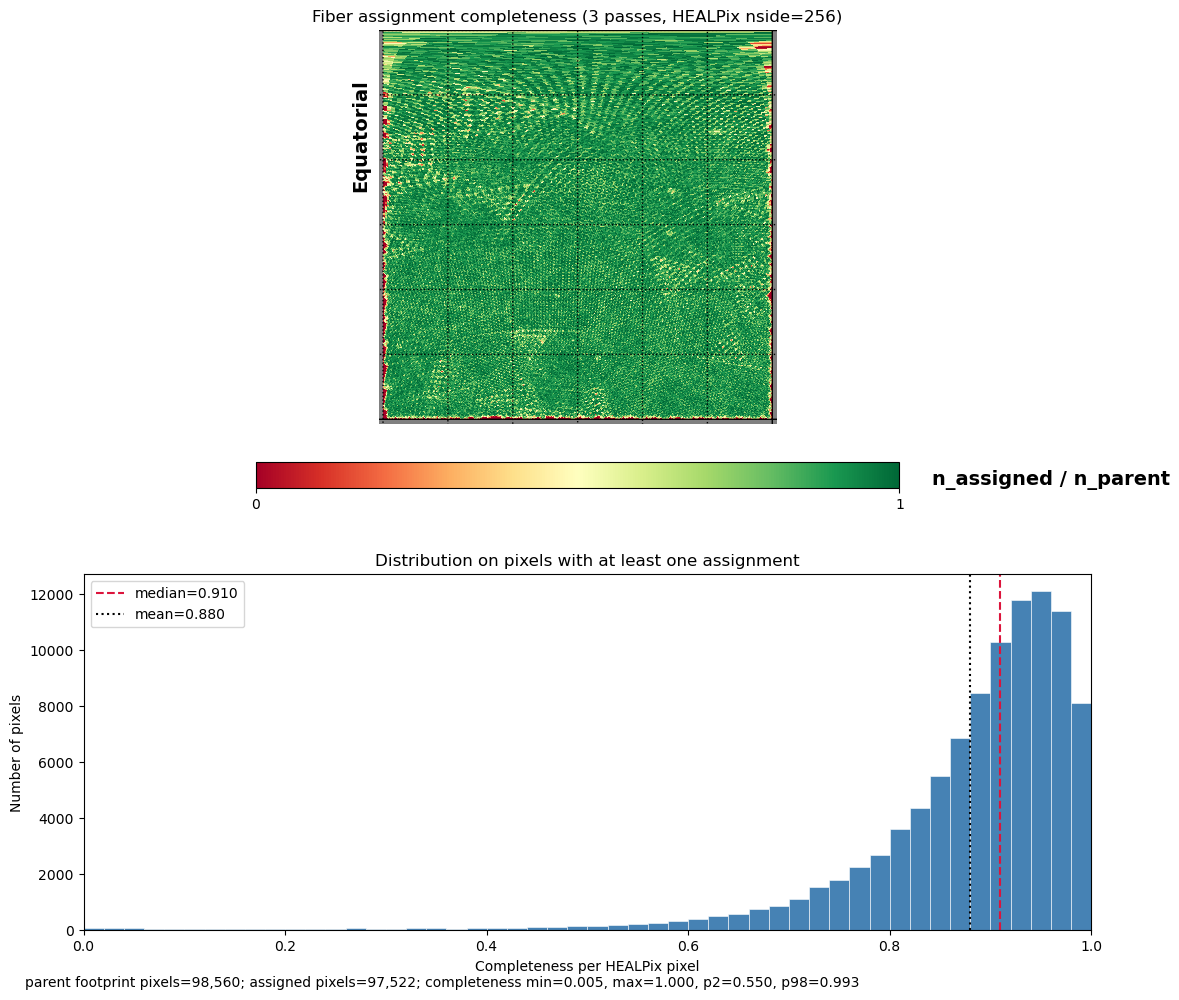

In [9]:
## show the heatmap of the completeness weight
ra_range = (
    float(np.min(cat_parent["ra"])),
    float(np.max(cat_parent["ra"])),
)
dec_range = (
    float(np.min(cat_parent["dec"])),
    float(np.max(cat_parent["dec"])),
)

weight_map = plot_completeness_map(
    count_fa,
    count_parent,
    nside,
    nest=nest,
    n_passes=Npasses,
    ra_range=ra_range,
    dec_range=dec_range,
)

Fiber assignment completeness: min=0.005, max=1.000


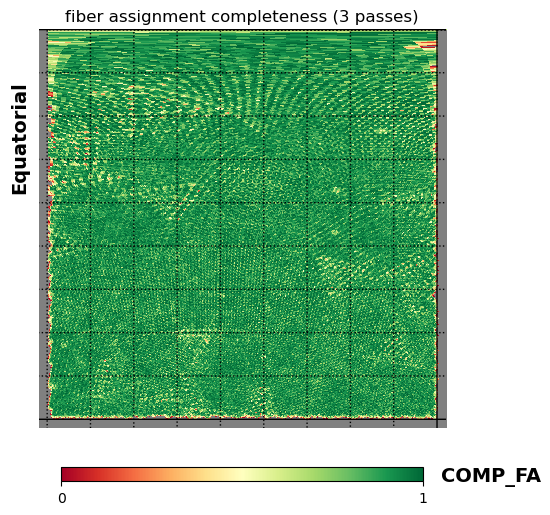

In [11]:
weight_map = np.full(hp.nside2npix(nside), hp.UNSEEN, dtype=np.float64)
assigned_pixels = count_fa > 0
weight_map[assigned_pixels] = (
    count_fa[assigned_pixels].astype(np.float64) / count_parent[assigned_pixels].astype(np.float64)
)

valid_weights = weight_map[assigned_pixels]
#vmin, vmax = np.percentile(valid_weights, [2, 98])
print(f"Fiber assignment completeness: min={valid_weights.min():.3f}, max={valid_weights.max():.3f}")
#print(f"Plot range (2-98 percentile): {vmin:.3f} to {vmax:.3f}")

hp.cartview(
    weight_map,
    nest=nest,
    coord="C",
    lonra=[-2, 92],
    latra=[-2, 90],
    min=0.0,
    max=1.0,
    title=f"fiber assignment completeness ({Npasses} passes)",
    unit="COMP_FA",
    cmap="RdYlGn",
    flip="astro",
)
hp.graticule(dmer=10, dpar=10, verbose=False)
plt.show()

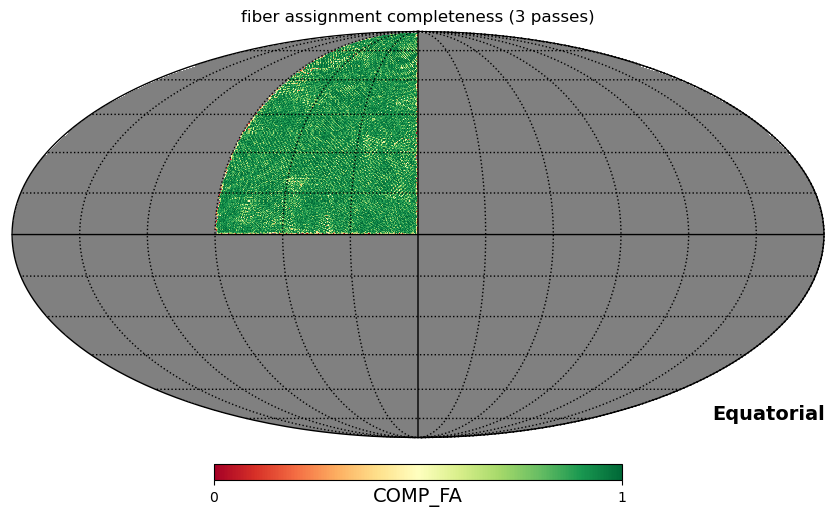

In [15]:
hp.mollview(
    weight_map,
    nest=nest,
    coord="C",
    min=0.0,
    max=1.0,
    title=f"fiber assignment completeness ({Npasses} passes)",
    unit="COMP_FA",
    cmap="RdYlGn",
    flip="astro",
)
hp.graticule(dmer=30, dpar=15, verbose=False)
plt.show()

In [16]:
comb_output = join(output, cat_parent, keys_left=["TARGETID"], keys_right=["idx"])
comb_output

TARGETID,TILES,FIBERS,COMP_FA,Mh,Mr,Ms,dec,gr,idx,index,mr,ra,type,z
int64,str64,str64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,int64,float64
0,107393-207394,154-1052,0.968503937007874,292610000000000.0,-23.18849199726835,11.462036032248465,41.29154120855546,0.19434165954589844,0,0,9.956809619034223,49.80819359215435,1,0.01465678246071711
2,207404,1382,0.7073170731707317,30740000000.0,-14.319385075304051,7.428143526326751,41.99001360921037,0.3145475387573242,2,2,18.782163312338206,51.97146451013884,1,0.017620778481114208
3,207419,1721,0.9836065573770492,46437000000.0,-14.599905494564513,7.399693165043393,39.507130787443195,0.09915733337402344,3,9,18.60793481161047,47.154312077790685,1,0.013867155944747855
5,207528-307528,309-1384,0.9918032786885246,309360000000.0,-19.13669895226123,9.73882457127641,40.04117445714175,0.8425216674804688,5,14,16.02601552059702,67.55782079772624,1,0.03388702431135027
6,207541-307541,723-1813,0.9526627218934911,117070000000.0,-17.7034040264618,8.808032997480932,40.12613247990758,0.47997474670410156,6,17,17.42267235087408,68.84936724135324,1,0.03588234956204839
7,107541-307528,586-1437,0.9918032786885246,231530000000.0,-18.562923603360137,9.642383691131789,39.875325900528445,0.8497428894042969,7,18,16.59382801007962,67.53256098013837,1,0.03392400346502655
8,207541,1312,0.9418604651162791,79792000000.0,-16.07441741201555,8.34817178537836,40.36759074556193,0.3656425476074219,8,19,19.054348508119194,68.4909460777121,1,0.03527082508276225
9,107592-207589-307585,1019-1715-413,0.9865771812080537,199940000000000.0,-22.083343183777373,11.397356562909454,34.62359352283776,0.9510231018066406,9,23,11.115302338484621,70.9323300483314,1,0.013880944725934707
10,207590,2170,0.8863636363636364,2139400000000.0,-20.681364577665157,10.569278434124076,33.11499063469242,0.7734394073486328,10,27,12.612713260922416,71.07337759234535,1,0.01272807844175694


In [17]:
odir = dir_root + "LSScats/"
os.makedirs(odir, exist_ok=True)

ofile = odir + "fba_cat.fits"
comb_output.write(ofile, overwrite=True)